# 99_analyze — Black-Litterman 실험 결과 분석

**역할**: `results/` 폴더의 pkl 파일을 로드해서 실험간 비교 분석.

## 구성
- **Section A** (항상): 성과 테이블, 누적수익률, 연도별 수익률, 포트폴리오 구성
- **Section B** (조건부): 바뀐 슬롯에 따라 자동 선택
  - P 슬롯 변경 → 변동성 분류 정확도 / 저위험 비중
  - Q 슬롯 변경 → Q 분포 / Q 시계열
  - Omega 슬롯 변경 → Omega 시계열 / 뷰 신뢰도
  - 거래비용 관련 → 턴오버 / TC 비용

> **실험 선택**: `TARGET` 리스트에 비교할 실험명 지정 (비어있으면 전체 로드)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pickle
import platform
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from bl_functions import compute_metrics
from bl_config import get_changed_slots, BASELINE

BASE_DIR    = Path.cwd()
DATA_DIR    = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'results'
OUT_DIR     = BASE_DIR / 'outputs' / '99_compare'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f'data/ 폴더 없음.\n경로: {DATA_DIR}'

ANN = np.sqrt(12)

# ── 비교할 실험 선택 (비어있으면 전체 로드) ──────────────────
TARGET = [
    
]

loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    name = pkl.stem
    if TARGET and name not in TARGET:
        continue
    with open(pkl, 'rb') as f:
        loaded[name] = pickle.load(f)

print(f'로드된 실험: {list(loaded.keys())}')

spy_ret_ref = loaded['baseline']['spy_ret'] if 'baseline' in loaded else list(loaded.values())[0]['spy_ret']

panel_rf = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                       usecols=['date','ticker','rf_1m'], parse_dates=['date'])
rf_monthly = panel_rf.groupby('date')['rf_1m'].first()

로드된 실험: ['baseline', 'capm_no_bl', 'naive_lowvol', 'naive_lowvol_rp', 'p_eq', 'p_rp', 'p_vol252', 'p_vol_mcap', 'prior_eq']


# A. 공통 분석 (모든 실험)

In [2]:
# ── A1. 성과 요약 테이블 ──────────────────────────────────────
spy_monthly = pd.read_csv(BASE_DIR / 'data' / 'monthly_panel.csv',
                          usecols=['date','ticker','spy_ret'], parse_dates=['date']
                         ).groupby('date')['spy_ret'].first()

rows = []
for name, res in loaded.items():
    ret = res['ret']
    if len(ret) == 0:
        continue
    m = compute_metrics(ret, rf_monthly, name, mkt_ret=spy_monthly)
    changed = get_changed_slots(res['config'])
    m['변경 슬롯'] = ', '.join(sorted(changed)) if changed else '—'
    rows.append(m)

# SPY 추가
spy_m = compute_metrics(spy_ret_ref.dropna(), rf_monthly, 'S&P 500 (SPY)', mkt_ret=spy_monthly)
spy_m['변경 슬롯'] = '—'
rows.append(spy_m)

perf_df = pd.DataFrame(rows).set_index('label')

# 표시 컬럼 선택 및 포맷
display_cols = ['sharpe', 'sortino', 'cagr', 'vol', 'mdd', 'calmar',
                'beta', 'alpha', 'win_rate', 'cvar_5', 'skewness', 'mdd_duration', '변경 슬롯']
pct_cols  = {'cagr', 'vol', 'mdd', 'alpha', 'win_rate', 'cvar_5'}

display_df = perf_df[display_cols].copy()
for col in pct_cols:
    if col in display_df.columns:
        display_df[col] = perf_df[col].map(lambda x: f'{x:.2%}' if not (isinstance(x, float) and np.isnan(x)) else 'N/A')

print('=' * 120)
print('전체 성과 요약')
print('=' * 120)
print(display_df.to_string())

전체 성과 요약
                 sharpe  sortino    cagr     vol      mdd  calmar   beta   alpha win_rate  cvar_5  skewness  mdd_duration             변경 슬롯
label                                                                                                                                      
baseline          1.106    1.726  13.37%  10.98%  -13.03%   1.026 -0.136  13.95%   67.80%  -6.07%    -0.207            14                 —
capm_no_bl        0.899    1.268  14.78%  15.13%  -22.19%   0.666 -0.149  15.52%   68.90%  -9.28%    -0.397            18            q_mode
naive_lowvol      1.061    1.549  13.86%  11.91%  -14.73%   0.941 -0.125  14.30%   67.20%  -6.88%    -0.347            22            q_mode
naive_lowvol_rp   1.017    1.450  13.47%  12.04%  -14.84%   0.908 -0.131  13.98%   68.90%  -7.31%    -0.396            22  p_weight, q_mode
p_eq              1.028    1.581  12.38%  10.86%  -12.85%   0.964 -0.124  12.80%   66.70%  -6.22%    -0.320            22          p_weight
p_rp       

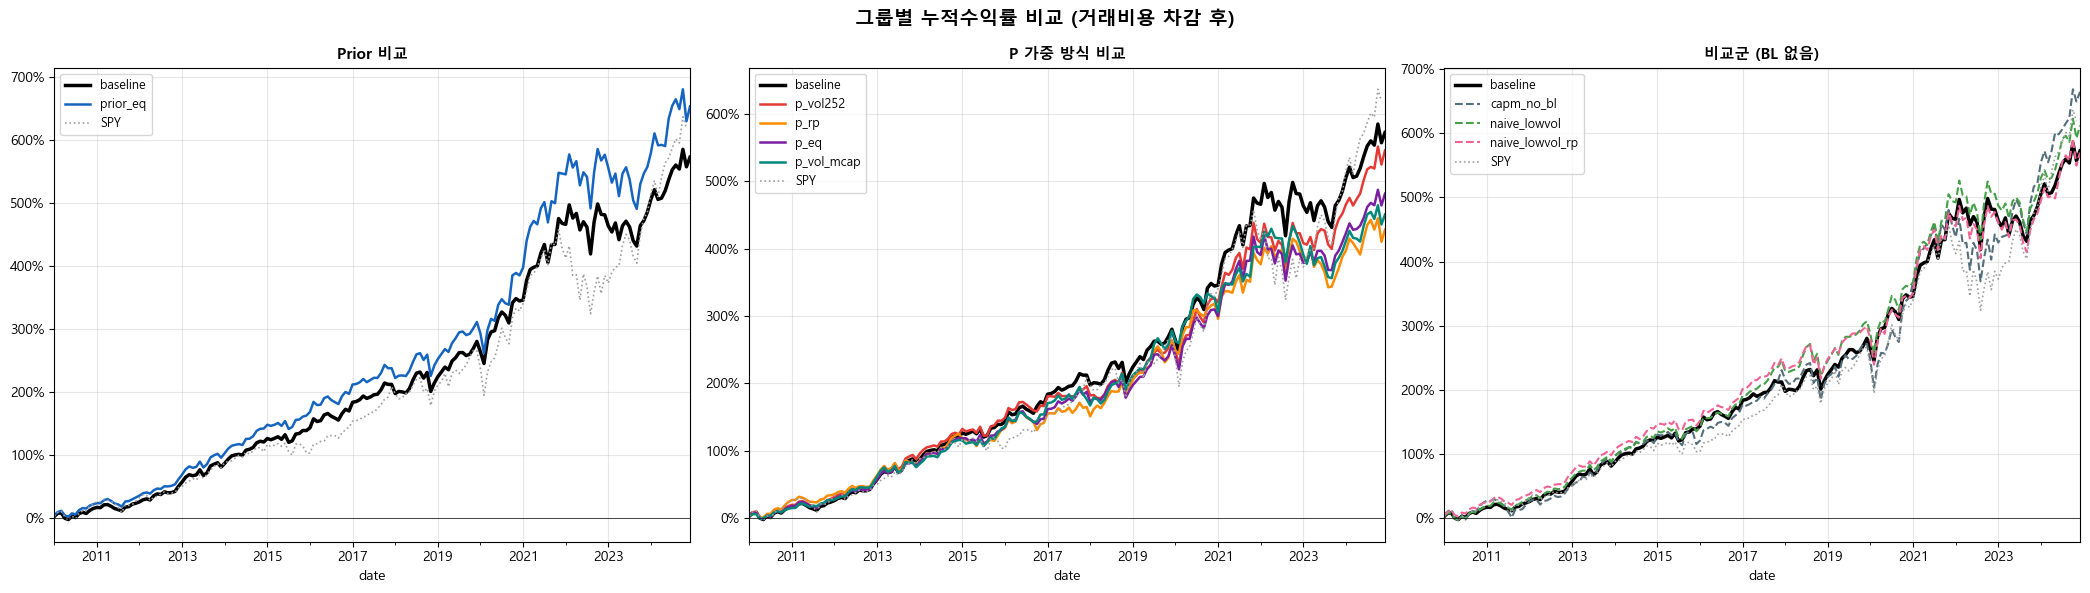

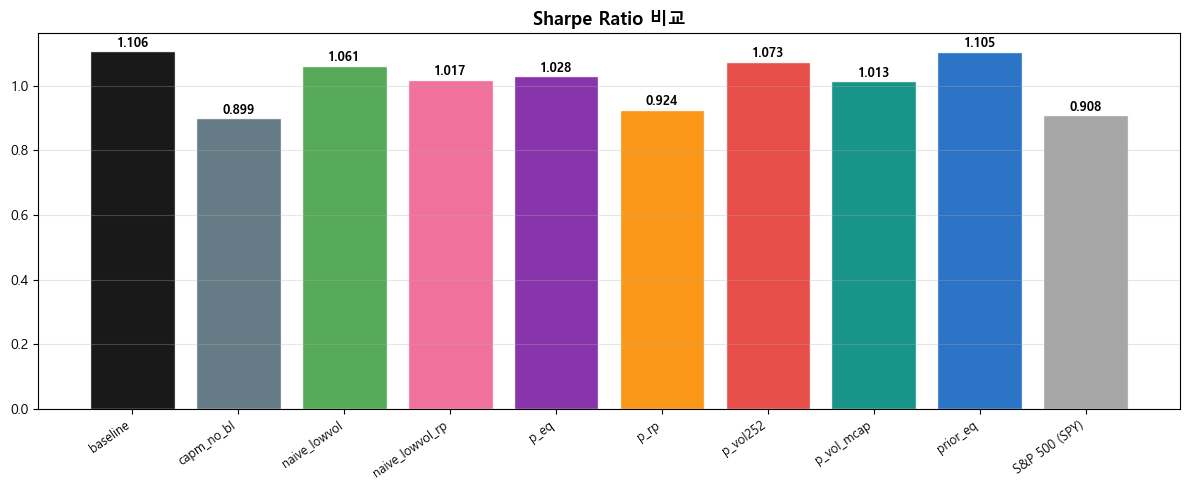

In [3]:
# ── A2. 누적수익률 비교 — 그룹별 분리 ────────────────────────
_exp_style = {
    'baseline'       : {'color': '#000000', 'lw': 2.5, 'ls': '-'},
    'prior_eq'       : {'color': '#1565C0', 'lw': 1.8, 'ls': '-'},
    'p_vol252'       : {'color': '#E53935', 'lw': 1.8, 'ls': '-'},
    'p_rp'           : {'color': '#FB8C00', 'lw': 1.8, 'ls': '-'},
    'p_eq'           : {'color': '#7B1FA2', 'lw': 1.8, 'ls': '-'},
    'p_vol_mcap'     : {'color': '#00897B', 'lw': 1.8, 'ls': '-'},
    'capm_no_bl'     : {'color': '#546E7A', 'lw': 1.5, 'ls': '--'},
    'naive_lowvol'   : {'color': '#43A047', 'lw': 1.5, 'ls': '--'},
    'naive_lowvol_rp': {'color': '#F06292', 'lw': 1.5, 'ls': '--'},
}
exp_colors = {n: s['color'] for n, s in _exp_style.items()}

groups = {
    'Prior 비교':        ['baseline', 'prior_eq'],
    'P 가중 방식 비교':  ['baseline', 'p_vol252', 'p_rp', 'p_eq', 'p_vol_mcap'],
    '비교군 (BL 없음)':  ['baseline', 'capm_no_bl', 'naive_lowvol', 'naive_lowvol_rp'],
}

spy_cum = (1 + spy_ret_ref.dropna()).cumprod() - 1

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('그룹별 누적수익률 비교 (거래비용 차감 후)', fontsize=14, fontweight='bold')

for ax, (title, names) in zip(axes, groups.items()):
    for name in names:
        if name not in loaded:
            continue
        ret = loaded[name]['ret']
        st  = _exp_style.get(name, {'color': '#BDBDBD', 'lw': 1.2, 'ls': '-'})
        (1 + ret).cumprod().sub(1).plot(
            ax=ax, label=name, color=st['color'], linewidth=st['lw'], linestyle=st['ls'])
    spy_cum.plot(ax=ax, label='SPY', color='#9E9E9E', lw=1.2, ls=':')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=9)
    ax.axhline(0, color='k', lw=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'A_cumret_groups.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
names_s  = list(perf_df.index)
sharpe_s = list(perf_df['sharpe'])
colors_s = [exp_colors.get(n, '#9E9E9E') for n in names_s]
bars = ax.bar(range(len(names_s)), sharpe_s, color=colors_s, alpha=0.9, edgecolor='white')
ax.set_xticks(range(len(names_s)))
ax.set_xticklabels(names_s, rotation=35, ha='right', fontsize=9)
ax.set_title('Sharpe Ratio 비교', fontsize=13, fontweight='bold')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, sharpe_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_sharpe_bar.png', dpi=150, bbox_inches='tight')
plt.show()

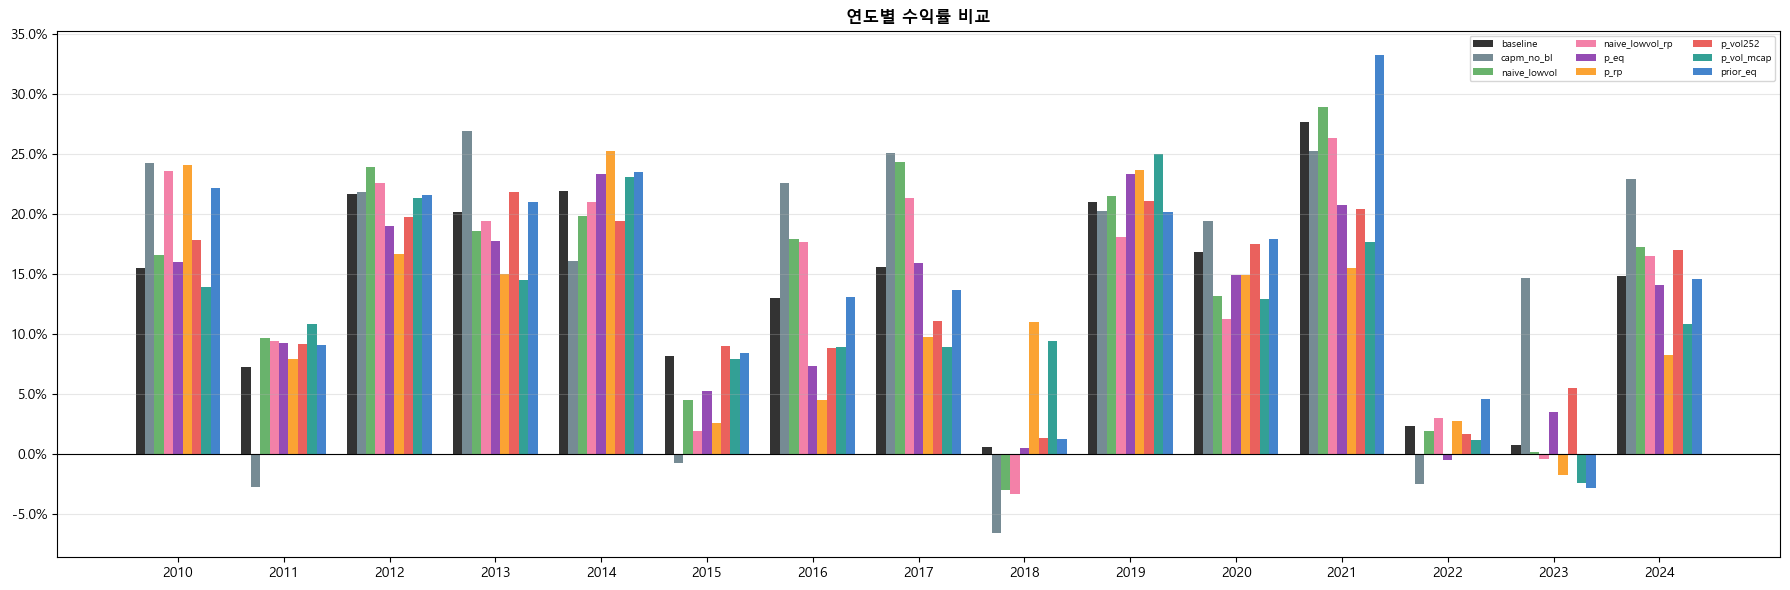

In [4]:
# ── A3. 연도별 수익률 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))
ax.set_title('연도별 수익률 비교', fontweight='bold')

all_years = sorted(set(y for res in loaded.values() for y in res['ret'].index.year))
x     = np.arange(len(all_years))
n_exp = len(loaded)
width = 0.8 / n_exp

for j, (name, res) in enumerate(loaded.items()):
    ret = res['ret'].copy()
    ret.index = pd.to_datetime(ret.index)
    ann   = [(1 + ret[ret.index.year == y]).prod() - 1 for y in all_years]
    color = exp_colors.get(name, '#BDBDBD')
    ax.bar(x + j * width - (n_exp - 1) * width / 2, ann,
           width, label=name, color=color, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='k', lw=0.8)
ax.legend(fontsize=7, ncol=3)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'A_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()

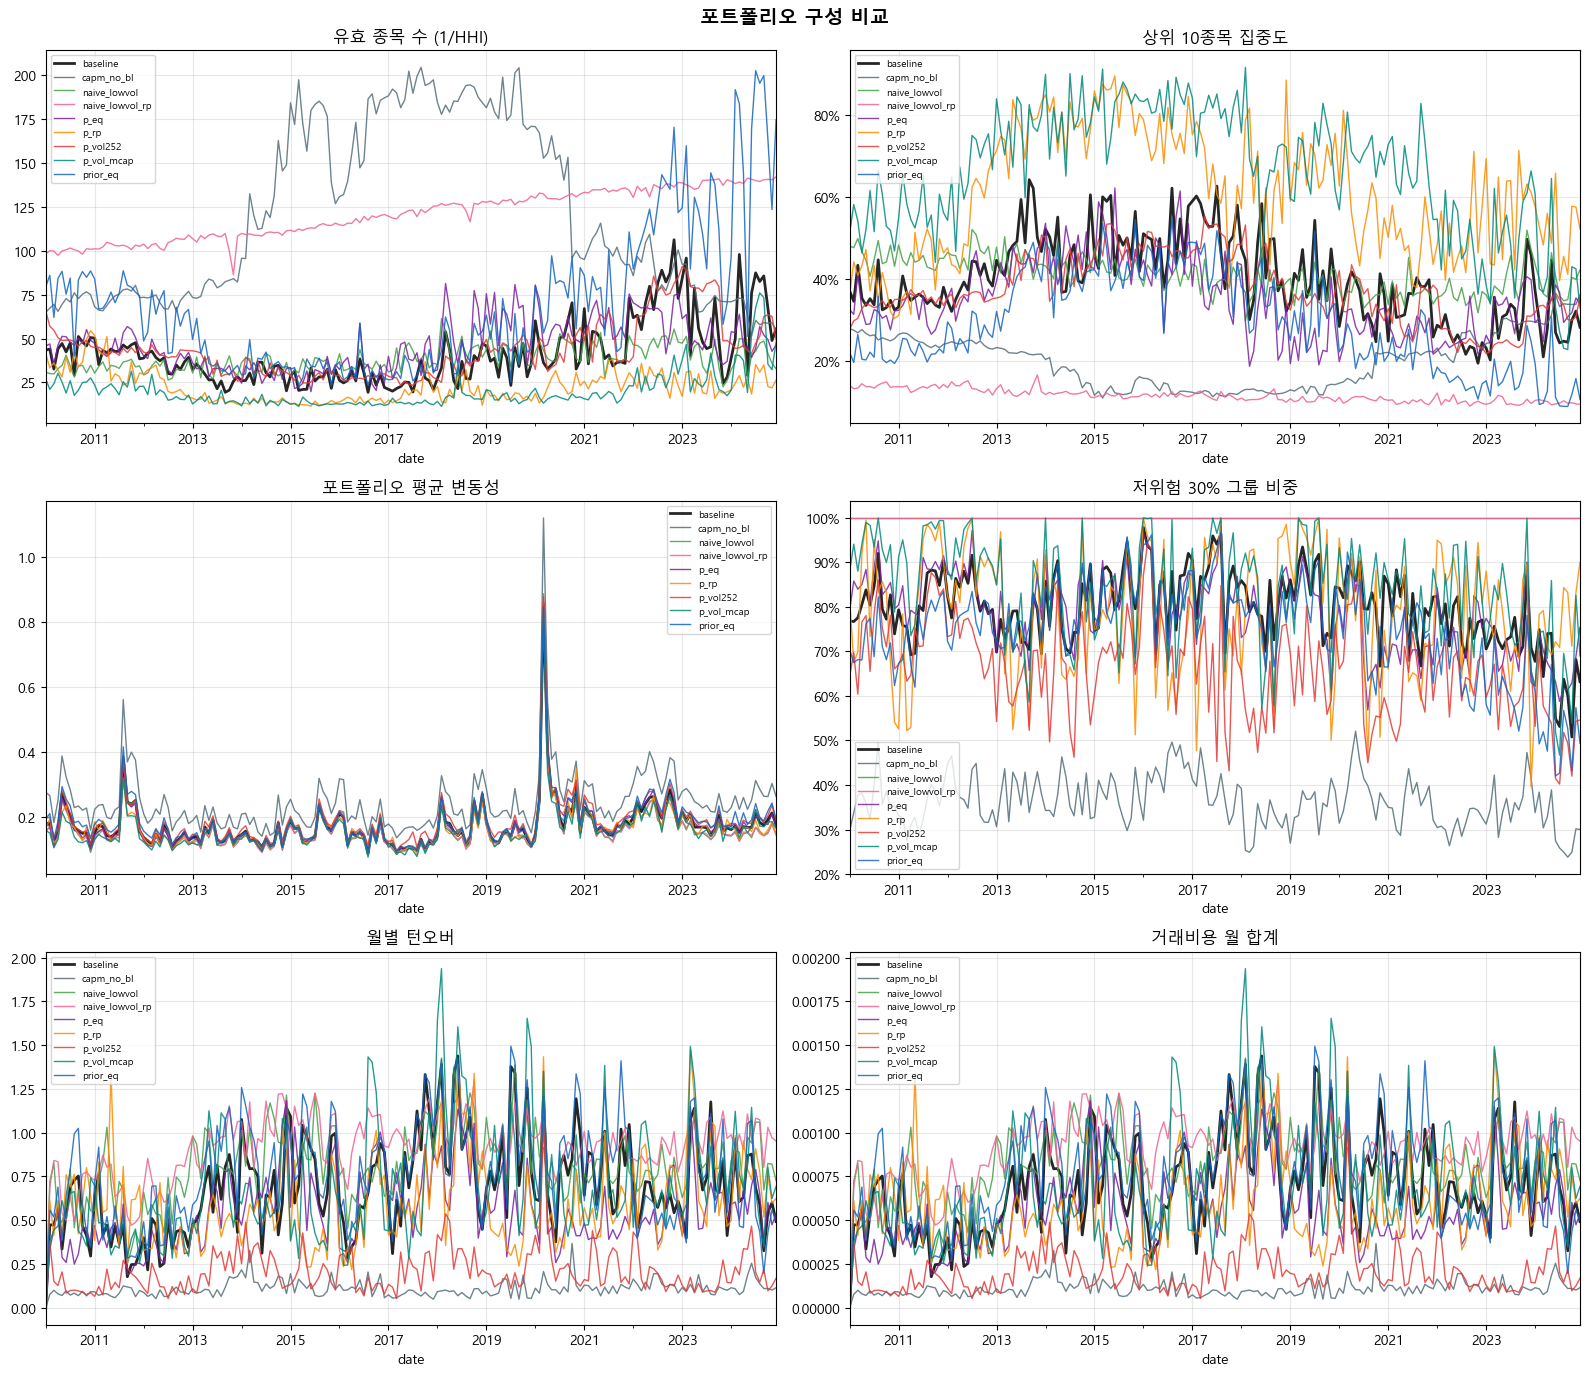


=== 포트폴리오 구성 평균값 ===
실험명                          유효N   Top10    평균vol     저위험W      턴오버     TC비용
---------------------------------------------------------------------------
baseline                    41.5   39.9%   0.1736    79.8%    0.692  0.00069
capm_no_bl                 119.3   20.2%   0.2470    36.2%    0.109  0.00011
naive_lowvol                38.1   41.0%   0.1630   100.0%    0.811  0.00081
naive_lowvol_rp            120.5   11.6%   0.1619   100.0%    0.913  0.00091
p_eq                        46.1   35.1%   0.1748    78.2%    0.561  0.00056
p_rp                        22.5   60.8%   0.1686    79.0%    0.598  0.00060
p_vol252                    43.8   37.5%   0.1869    66.3%    0.206  0.00021
p_vol_mcap                  20.1   66.3%   0.1608    84.0%    0.690  0.00069
prior_eq                    68.5   29.5%   0.1841    74.5%    0.765  0.00077


In [5]:
# ── A4. 포트폴리오 구성 비교 ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('포트폴리오 구성 비교', fontsize=14, fontweight='bold')

metrics_comp = [
    ('eff_n',        '유효 종목 수 (1/HHI)',       None),
    ('top10_share',  '상위 10종목 집중도',          mtick.PercentFormatter(1.0)),
    ('avg_vol',      '포트폴리오 평균 변동성',       None),
    ('low_weight',   '저위험 30% 그룹 비중',        mtick.PercentFormatter(1.0)),
    ('turnover',     '월별 턴오버',                 None),
    ('tc_cost',      '거래비용 월 합계',             None),
]

for ax, (col, title, formatter) in zip(axes.flat, metrics_comp):
    for name, res in loaded.items():
        comp = res.get('comp', pd.DataFrame())
        if comp.empty or col not in comp.columns:
            continue
        color = exp_colors.get(name, '#BDBDBD')
        lw    = 2.0 if name == 'baseline' else 1.0
        comp[col].plot(ax=ax, label=name, color=color, linewidth=lw, alpha=0.85)
    ax.set_title(title)
    if formatter:
        ax.yaxis.set_major_formatter(formatter)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'A_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== 포트폴리오 구성 평균값 ===')
print(f"{'실험명':<25} {'유효N':>6} {'Top10':>7} {'평균vol':>8} {'저위험W':>8} {'턴오버':>8} {'TC비용':>8}")
print('-' * 75)
for name, res in loaded.items():
    comp = res.get('comp', pd.DataFrame())
    if comp.empty:
        continue
    print(f"{name:<25} "
          f"{comp['eff_n'].mean():>6.1f} "
          f"{comp['top10_share'].mean():>7.1%} "
          f"{comp['avg_vol'].mean():>8.4f} "
          f"{comp['low_weight'].mean():>8.1%} "
          f"{comp['turnover'].mean():>8.3f} "
          f"{comp['tc_cost'].mean():>8.5f}")

# B. 조건부 분석 (변경된 슬롯에 따라 자동 실행)

In [6]:
q_exps = {n: r for n, r in loaded.items()
          if 'q_mode' in get_changed_slots(r['config'])
          or 'q_value' in get_changed_slots(r['config'])}
print('B1: Q 슬롯 변경 실험 없음 — 스킵' if not q_exps else f'B1: {list(q_exps.keys())}')

B1: ['capm_no_bl', 'naive_lowvol', 'naive_lowvol_rp']


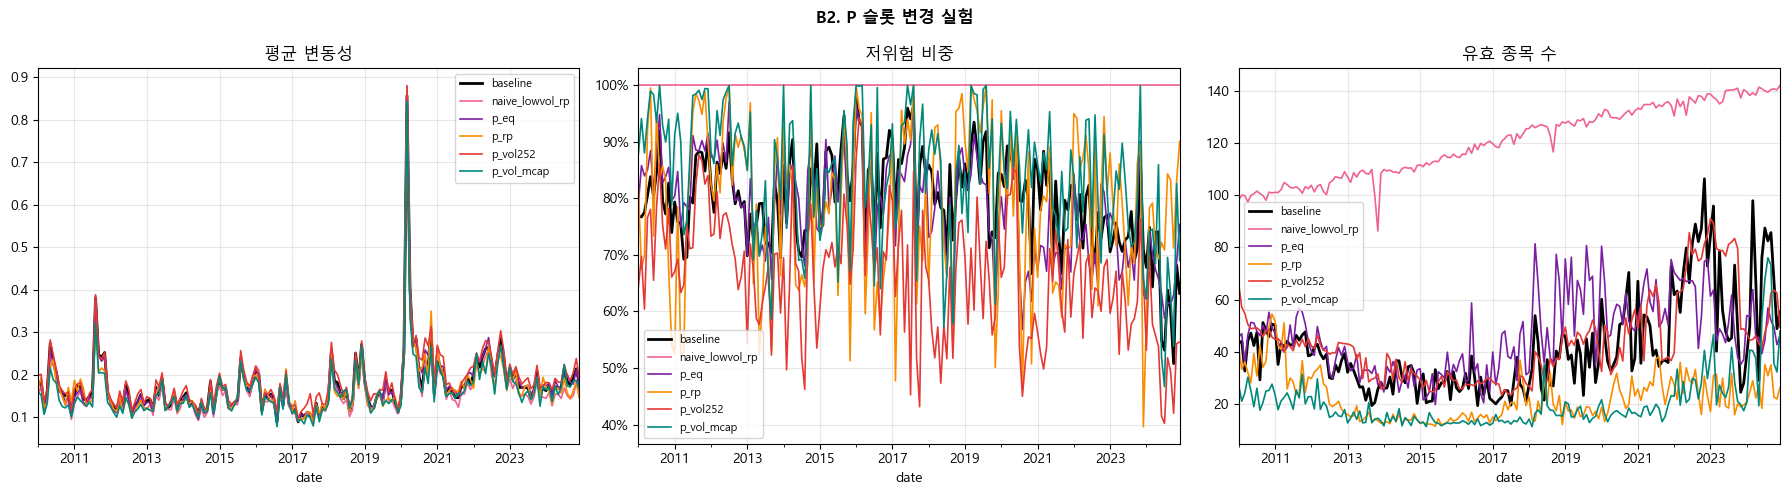

In [7]:
p_exps = {n: r for n, r in loaded.items()
          if 'p_mode' in get_changed_slots(r['config'])
          or 'p_weight' in get_changed_slots(r['config'])}
p_exps_all = {'baseline': loaded['baseline']} | p_exps if 'baseline' in loaded else p_exps

if p_exps:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('B2. P 슬롯 변경 실험', fontweight='bold')
    for name, res in p_exps_all.items():
        comp = res.get('comp', pd.DataFrame())
        if comp.empty: continue
        color = exp_colors.get(name, '#BDBDBD')
        lw    = 2.0 if name == 'baseline' else 1.2
        comp['avg_vol'].plot(ax=axes[0], label=name, color=color, linewidth=lw)
        comp['low_weight'].plot(ax=axes[1], label=name, color=color, linewidth=lw)
        comp['eff_n'].plot(ax=axes[2], label=name, color=color, linewidth=lw)
    axes[0].set_title('평균 변동성'); axes[1].set_title('저위험 비중'); axes[2].set_title('유효 종목 수')
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for ax in axes: ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'B2_P_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('B2: P 슬롯 변경 실험 없음 — 스킵')

In [8]:
om_exps = {n: r for n, r in loaded.items()
           if 'omega_mode' in get_changed_slots(r['config'])
           or 'omega_scale' in get_changed_slots(r['config'])}
print('B3: Omega 슬롯 변경 실험 없음 — 스킵' if not om_exps else f'B3: {list(om_exps.keys())}')

B3: Omega 슬롯 변경 실험 없음 — 스킵


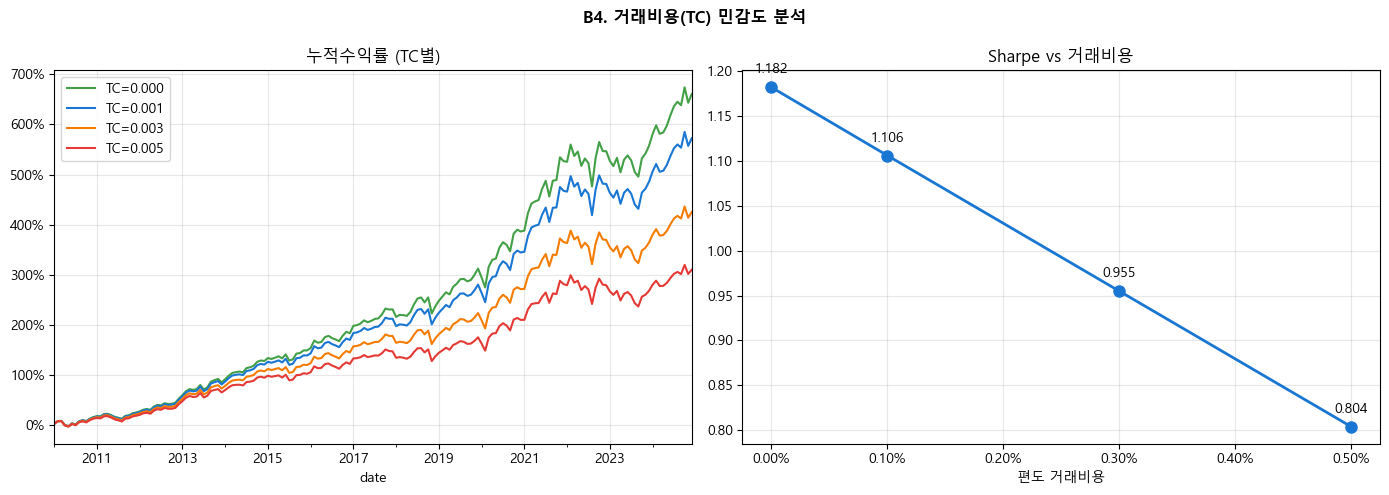

In [9]:
# ── B4. 거래비용 민감도 ───────────────────────────────────────
# baseline으로 TC를 0 / 0.001 / 0.003 / 0.005로 바꾸면서 Sharpe 비교
# (results에 있으면 로드, 없으면 건너뜀)

from bl_functions import apply_tc, compute_turnover

if 'baseline' in loaded:
    base_res  = loaded['baseline']
    base_comp = base_res['comp']

    tc_levels = [0.0, 0.001, 0.003, 0.005]
    tc_results = {}

    for tc_val in tc_levels:
        gross = base_res['gross_ret']
        turn  = base_comp['turnover'] if 'turnover' in base_comp.columns else pd.Series(0.0, index=gross.index)
        net   = gross - turn.reindex(gross.index).fillna(0) * tc_val
        tc_results[f'TC={tc_val:.3f}'] = net

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('B4. 거래비용(TC) 민감도 분석', fontweight='bold')

    tc_colors = ['#43A047', '#1976D2', '#F57C00', '#E53935']
    for (label, ret), color in zip(tc_results.items(), tc_colors):
        (1 + ret).cumprod().sub(1).plot(ax=axes[0], label=label, color=color, linewidth=1.5)

    axes[0].set_title('누적수익률 (TC별)')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    sharpes_tc = [compute_metrics(ret, rf_monthly)['sharpe'] for ret in tc_results.values()]
    axes[1].plot(tc_levels, sharpes_tc, 'o-', color='#1976D2', linewidth=2, markersize=8)
    for x, y in zip(tc_levels, sharpes_tc):
        axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
    axes[1].set_title('Sharpe vs 거래비용')
    axes[1].set_xlabel('편도 거래비용')
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'B4_tc_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('B4: baseline 없음 → TC 민감도 스킵')

In [10]:
# ── C. 최종 요약 ──────────────────────────────────────────────
print('=' * 90)
print('최종 비교 요약')
print('=' * 90)

# Sharpe 기준 정렬
summary = perf_df[['sharpe', 'cagr', 'vol', 'mdd', '변경 슬롯']].copy()
summary = summary.sort_values('sharpe', ascending=False)
summary['cagr'] = summary['cagr'].map('{:.2%}'.format)
summary['vol']  = summary['vol'].map('{:.2%}'.format)
summary['mdd']  = summary['mdd'].map('{:.2%}'.format)
print(summary.to_string())

print(f'\n저장된 차트: {list(OUT_DIR.glob("*.png"))}')

최종 비교 요약
                 sharpe    cagr     vol      mdd             변경 슬롯
label                                                             
baseline          1.106  13.37%  10.98%  -13.03%                 —
prior_eq          1.105  14.22%  11.75%  -13.86%             prior
p_vol252          1.073  13.11%  11.09%  -13.10%            p_mode
naive_lowvol      1.061  13.86%  11.91%  -14.73%            q_mode
p_eq              1.028  12.38%  10.86%  -12.85%          p_weight
naive_lowvol_rp   1.017  13.47%  12.04%  -14.84%  p_weight, q_mode
p_vol_mcap        1.013  11.99%  10.62%  -14.46%          p_weight
p_rp              0.924  11.79%  11.45%  -13.96%          p_weight
S&P 500 (SPY)     0.908  14.35%  14.54%  -23.93%                 —
capm_no_bl        0.899  14.78%  15.13%  -22.19%            q_mode

저장된 차트: [WindowsPath('c:/workspace/camp/project/finance_project/final/outputs/99_compare/A_annual_returns.png'), WindowsPath('c:/workspace/camp/project/finance_project/final/outputs/99_c